# Lista 3 - Visão Computacional
Alunos: José Matheus Santana Alves e Ycaro Bruno Souza Sales

In [2]:
import pandas as pd
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import glob

## Questão 1

In [1]:
def get_good_matches(matches):
    good = []
    for i,(m,n) in enumerate(matches):
        if m.distance < 0.7*n.distance:
            good.append(m)
    return good


def ransac(img1, img2, kp1, kp2, matches, MIN_MATCH_COUNT = 10):
    matchesMask = [[0,0] for i in range(len(matches))]

    good = get_good_matches(matches)

    if len(good) > MIN_MATCH_COUNT:
        src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
        dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)

        # find homography that maps points from img1 -> img2
        M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)
        if mask is not None:
            matchesMask = mask.ravel().tolist()
        else:
            matchesMask = None

        if M is None:
            return img1.copy(), matchesMask, good

        # We want to warp img2 into img1 coordinate frame. Invert M (img1->img2) to get H (img2->img1)
        try:
            H = np.linalg.inv(M)
        except np.linalg.LinAlgError:
            return img1.copy(), matchesMask, good

        h1, w1 = img1.shape[:2]
        h2, w2 = img2.shape[:2]

        # corners of img2 in img1 coord
        corners_img2 = np.float32([[0,0],[0,h2-1],[w2-1,h2-1],[w2-1,0]]).reshape(-1,1,2)
        warped_corners = cv.perspectiveTransform(corners_img2, H)

        # corners of img1
        corners_img1 = np.float32([[0,0],[0,h1-1],[w1-1,h1-1],[w1-1,0]]).reshape(-1,1,2)

        all_corners = np.vstack((warped_corners, corners_img1))
        [xmin, ymin] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
        [xmax, ymax] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

        # translation to keep everything positive
        tx = -xmin if xmin < 0 else 0
        ty = -ymin if ymin < 0 else 0

        pano_width = xmax - xmin +1
        pano_height = ymax - ymin +1

        # warp img2 into panorama using translation * H
        translation = np.array([[1, 0, tx],[0, 1, ty],[0,0,1]])
        warped_img2 = cv.warpPerspective(img2, translation.dot(H), (pano_width, pano_height))

        # create panorama and paste img1 at its translated position
        panorama = warped_img2.copy()
        panorama[ty:ty+h1, tx:tx+w1] = img1

    else:
        matchesMask = None
        panorama = img1.copy()

    return panorama, matchesMask, good

(np.float64(-0.5), np.float64(2317.5), np.float64(2661.5), np.float64(-0.5))

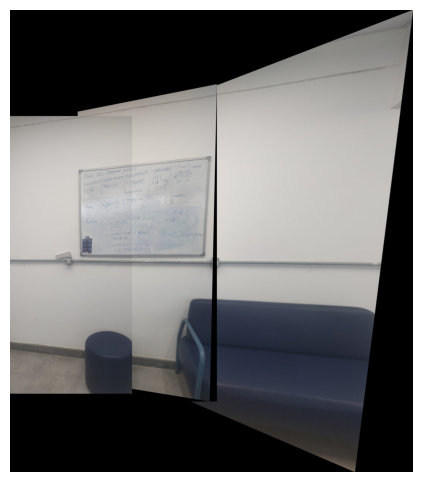

In [3]:
sift = cv.SIFT_create()
img1 = cv.imread('./assets/1_1.jpeg')
img2 = cv.imread('./assets/1_2.jpeg')
img3 = cv.imread('./assets/1_3.jpeg')
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)
kp3, des3 = sift.detectAndCompute(img3, None)

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv.FlannBasedMatcher(index_params, search_params)

# stitch img1 and img2 first
matches12 = flann.knnMatch(des1, des2, k=2)
pan12, matchesMask12, good12 = ransac(img1, img2, kp1, kp2, matches12, 5)

# now detect features on the panorama and match with img3
kp_pan, des_pan = sift.detectAndCompute(pan12, None)
matches_pan3 = flann.knnMatch(des_pan, des3, k=2)
panorama_final, matchesMask3, good3 = ransac(pan12, img3, kp_pan, kp3, matches_pan3, 5)
# convert BGR->RGB for matplotlib
panorama_rgb = cv.cvtColor(panorama_final, cv.COLOR_BGR2RGB)
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.imshow(panorama_rgb)
plt.axis('off')

(np.float64(-0.5), np.float64(2593.5), np.float64(2893.5), np.float64(-0.5))

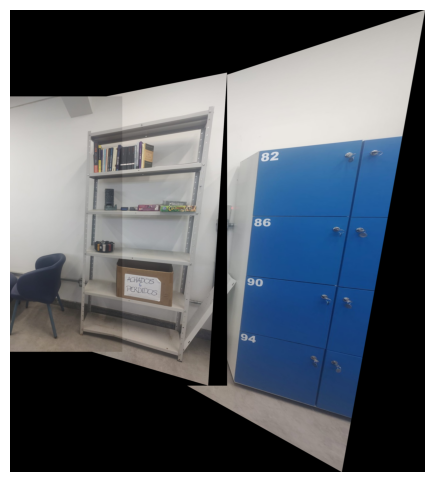

In [4]:
sift = cv.SIFT_create()
img1 = cv.imread('./assets/2_1.jpeg')
img2 = cv.imread('./assets/2_2.jpeg')
img3 = cv.imread('./assets/2_3.jpeg')
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)
kp3, des3 = sift.detectAndCompute(img3, None)

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv.FlannBasedMatcher(index_params, search_params)

# stitch img1 and img2 first
matches12 = flann.knnMatch(des1, des2, k=2)
pan12, matchesMask12, good12 = ransac(img1, img2, kp1, kp2, matches12, 5)

# now detect features on the panorama and match with img3
kp_pan, des_pan = sift.detectAndCompute(pan12, None)
matches_pan3 = flann.knnMatch(des_pan, des3, k=2)
panorama_final, matchesMask3, good3 = ransac(pan12, img3, kp_pan, kp3, matches_pan3, 5)
# convert BGR->RGB for matplotlib
panorama_rgb = cv.cvtColor(panorama_final, cv.COLOR_BGR2RGB)
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.imshow(panorama_rgb)
plt.axis('off')

(np.float64(-0.5), np.float64(1748.5), np.float64(1898.5), np.float64(-0.5))

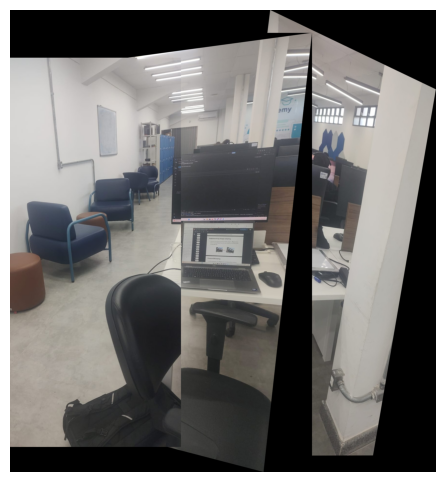

In [5]:
sift = cv.SIFT_create()
img1 = cv.imread('./assets/3_1.jpeg')
img2 = cv.imread('./assets/3_2.jpeg')
img3 = cv.imread('./assets/3_3.jpeg')
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)
kp3, des3 = sift.detectAndCompute(img3, None)

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv.FlannBasedMatcher(index_params, search_params)

# stitch img1 and img2 first
matches12 = flann.knnMatch(des1, des2, k=2)
pan12, matchesMask12, good12 = ransac(img1, img2, kp1, kp2, matches12, 5)

# now detect features on the panorama and match with img3
kp_pan, des_pan = sift.detectAndCompute(pan12, None)
matches_pan3 = flann.knnMatch(des_pan, des3, k=2)
panorama_final, matchesMask3, good3 = ransac(pan12, img3, kp_pan, kp3, matches_pan3, 5)
# convert BGR->RGB for matplotlib
panorama_rgb = cv.cvtColor(panorama_final, cv.COLOR_BGR2RGB)
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.imshow(panorama_rgb)
plt.axis('off')

(np.float64(-0.5), np.float64(1490.5), np.float64(1598.5), np.float64(-0.5))

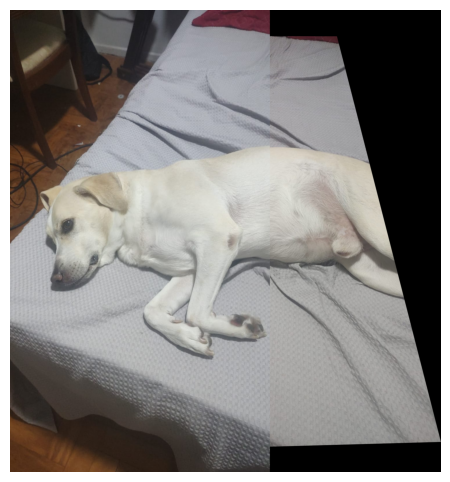

In [6]:
sift = cv.SIFT_create()
img1 = cv.imread('./assets/4_1.jpeg')
img2 = cv.imread('./assets/4_2.jpeg')
img3 = cv.imread('./assets/4_3.jpeg')
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)
kp3, des3 = sift.detectAndCompute(img3, None)

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv.FlannBasedMatcher(index_params, search_params)

# stitch img1 and img2 first
matches12 = flann.knnMatch(des1, des2, k=2)
pan12, matchesMask12, good12 = ransac(img1, img2, kp1, kp2, matches12, 5)

# now detect features on the panorama and match with img3
kp_pan, des_pan = sift.detectAndCompute(pan12, None)
matches_pan3 = flann.knnMatch(des_pan, des3, k=2)
panorama_final, matchesMask3, good3 = ransac(pan12, img3, kp_pan, kp3, matches_pan3, 5)
# convert BGR->RGB for matplotlib
panorama_rgb = cv.cvtColor(panorama_final, cv.COLOR_BGR2RGB)
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.imshow(panorama_rgb)
plt.axis('off')

(np.float64(-0.5), np.float64(3276.5), np.float64(3449.5), np.float64(-0.5))

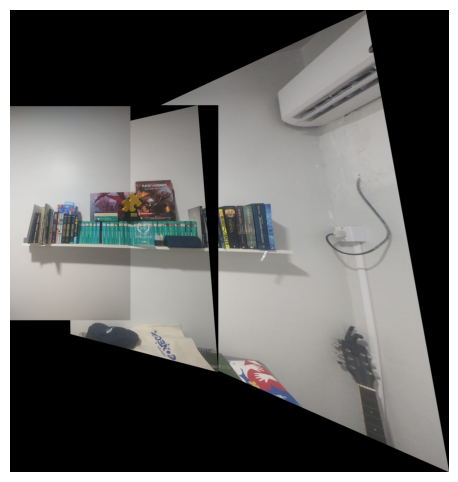

In [7]:
sift = cv.SIFT_create()
img1 = cv.imread('./assets/5_1.jpeg')
img2 = cv.imread('./assets/5_2.jpeg')
img3 = cv.imread('./assets/5_3.jpeg')
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)
kp3, des3 = sift.detectAndCompute(img3, None)

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv.FlannBasedMatcher(index_params, search_params)

# stitch img1 and img2 first
matches12 = flann.knnMatch(des1, des2, k=2)
pan12, matchesMask12, good12 = ransac(img1, img2, kp1, kp2, matches12, 5)

# now detect features on the panorama and match with img3
kp_pan, des_pan = sift.detectAndCompute(pan12, None)
matches_pan3 = flann.knnMatch(des_pan, des3, k=2)
panorama_final, matchesMask3, good3 = ransac(pan12, img3, kp_pan, kp3, matches_pan3, 5)
# convert BGR->RGB for matplotlib
panorama_rgb = cv.cvtColor(panorama_final, cv.COLOR_BGR2RGB)
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.imshow(panorama_rgb)
plt.axis('off')

## Questão 2

In [ ]:
pts = []

def selecionar_pontos(event, x, y, flags, param):
    global pts
    if event == cv.EVENT_LBUTTONUP:
        cv.circle(img_soccer, (x, y), 2, (0, 0, 255), -1)
        pts.append([x, y])
        print(f"Ponto registrado: {x, y} - Total: {len(pts)}/4")

img_soccer = cv.imread('soccer.jpg')
img_original = img_soccer.copy()
largura_maxima = 1400
escala_redimensionamento = largura_maxima / img_soccer.shape[1]
nova_altura = int(img_soccer.shape[0] * escala_redimensionamento)
img_soccer = cv.resize(img_soccer, (largura_maxima, nova_altura))

cv.namedWindow('Selecione as quinas da Grande Area')
cv.setMouseCallback('Selecione as quinas da Grande Area', selecionar_pontos)

print("1. Quina Inferior da Área Esquerda")
print("2. Quina Inferior da Área Direita")
print("3. Quina Superior da Área Esquerda")
print("4. Quina Superior da Área Direita")

while True:
    cv.imshow('Selecione as quinas da Grande Area', img_soccer)
    k = cv.waitKey(20) & 0xFF
    if k == 27:
        if len(pts) == 4:
            break

cv.destroyAllWindows()

escala = 10

largura_campo = 105
altura_campo = 68

x_esquerdo = 16.5
x_direito = largura_campo - 16.5 
y_inferior = (altura_campo - 40.32) / 2 
y_superior = y_inferior + 40.32 


y_inf_cv = (altura_campo - y_inferior) * escala
y_sup_cv = (altura_campo - y_superior) * escala
x_esq_cv = x_esquerdo * escala
x_dir_cv = x_direito * escala

pts_mapa = np.float32([
    [x_esq_cv, y_inf_cv], # 1. Inferior Esquerdo
    [x_dir_cv, y_inf_cv], # 2. Inferior Direito
    [x_esq_cv, y_sup_cv], # 3. Superior Esquerdo
    [x_dir_cv, y_sup_cv]  # 4. Superior Direito
])

pts = np.float32(pts)


H, mask = cv.findHomography(pts, pts_mapa, cv.RANSAC, 5.0)


pts_original = pts / escala_redimensionamento
H_alta_res, mask2 = cv.findHomography(pts_original, pts_mapa, cv.RANSAC, 5.0)

dimensao_imagem_final = (largura_campo * escala, altura_campo * escala)
mapa_2d = cv.warpPerspective(img_original, H_alta_res, dimensao_imagem_final)

nome_arquivo = 'campo_mapa_area.png'
cv.imwrite(nome_arquivo, mapa_2d)

1. Quina Inferior da Área Esquerda
2. Quina Inferior da Área Direita
3. Quina Superior da Área Esquerda
4. Quina Superior da Área Direita
Ponto registrado: (353, 367) - Total: 1/4
Ponto registrado: (641, 701) - Total: 2/4
Ponto registrado: (756, 313) - Total: 3/4
Ponto registrado: (1124, 615) - Total: 4/4


True

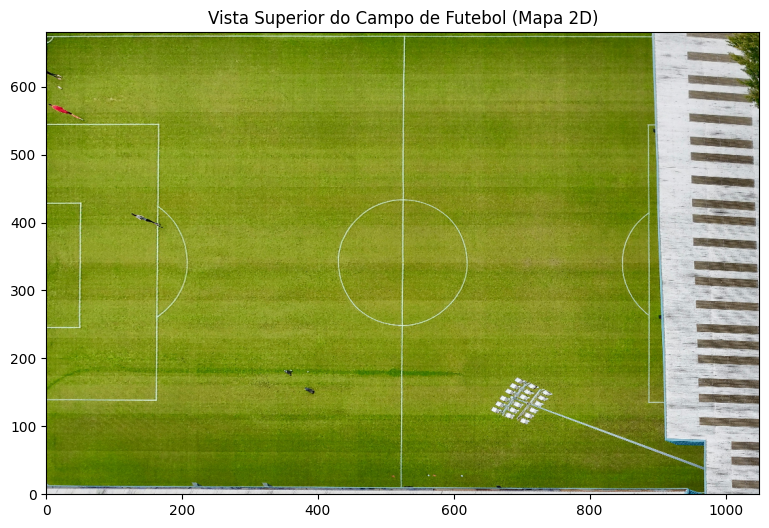

In [26]:
mapa_2d = cv.imread("campo_mapa_area.png")
mapa_2d_rgb = cv.cvtColor(mapa_2d, cv.COLOR_BGR2RGB)

altura, largura = mapa_2d_rgb.shape[:2]

plt.figure(figsize=(10, 6)) 
plt.imshow(mapa_2d_rgb, extent=[0, largura, 0, altura])
plt.title('Vista Superior do Campo de Futebol (Mapa 2D)')



plt.show()

In [ ]:
pts_selecionados = []
altura = mapa_2d.shape[0]

def capturar_clique(event, x, y, flags, param):
    global pts_selecionados
    
    if event == cv.EVENT_LBUTTONDOWN:
        y_invertido = altura - y
        pts_selecionados.append((x, y_invertido))
        print(f"Ponto {len(pts_selecionados)} selecionado: X={x}, Y={y_invertido}")
        
        cv.circle(mapa_2d, (x, y), 5, (255, 0, 0), -1)
        cv.imshow('Selecione 2 pontos', mapa_2d)

cv.namedWindow('Selecione 2 pontos', cv.WINDOW_AUTOSIZE)
cv.setMouseCallback('Selecione 2 pontos', capturar_clique)

while True:
    cv.imshow('Selecione 2 pontos', mapa_2d)
    
    k = cv.waitKey(20) & 0xFF
    if k == 27:
        print("Operação cancelada")
        break
    
    if len(pts_selecionados) == 2:
        cv.waitKey(500)
        break

cv.destroyAllWindows()

if len(pts_selecionados) == 2:
    print("\n--- Resultado ---")
    print(f"Ponto 1: {pts_selecionados[0]}")
    print(f"Ponto 2: {pts_selecionados[1]}")

Ponto 1 selecionado: X=19, Y=616
Ponto 2 selecionado: X=55, Y=553

--- Resultado ---
Ponto 1: (19, 616)
Ponto 2: (55, 553)


## Questão 3

In [6]:
square_size = 2.0  # cm

criteria = (
    cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER,
    30,
    0.001
)

# tabuleiro 7x7 cantos internos
objp = np.zeros((49, 3), np.float32)

for i in range(7):
    for j in range(7):
        objp[i * 7 + j] = [
            (j + 1) * square_size,
            (7 - i) * square_size,
            0
        ]

objpoints = []
imgpoints = []

images = ['chess1.jpeg', 'chess2.jpeg', 'chess3.jpeg']

for fname in images:
    img = cv.imread(fname)

    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    found, corners = cv.findChessboardCorners(gray, (7, 7))

    if found:
        corners = cv.cornerSubPix(
            gray,
            corners,
            (11, 11),
            (-1, -1),
            criteria
        )

        objpoints.append(objp)
        imgpoints.append(corners)

if len(objpoints) == 0:
    print('Nenhum tabuleiro encontrado.')

ret, mtx, dist, rvecs, tvecs = cv.calibrateCamera(
    objpoints,
    imgpoints,
    gray.shape[::-1],
    None,
    None
)


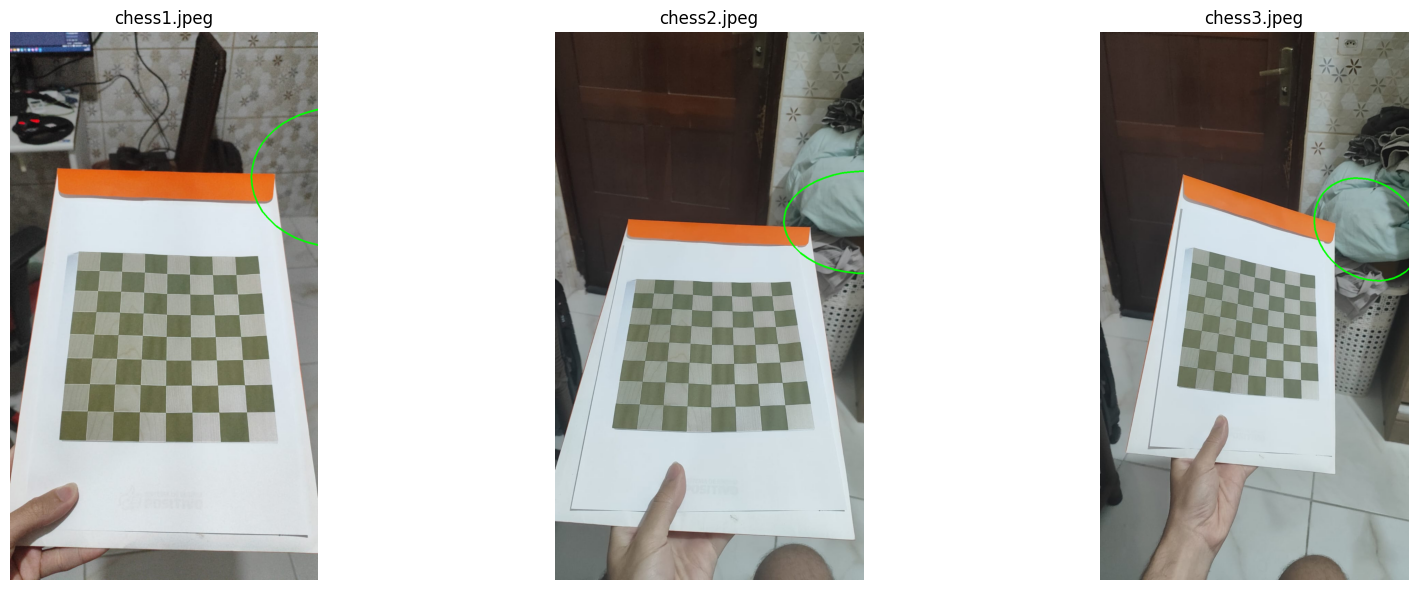

In [7]:
W = 8 * square_size
H = 8 * square_size
r = 0.5 * W

theta = np.linspace(0, 2 * np.pi, 50)

x = r * np.cos(theta) + 1.5 * W
y = r * np.sin(theta) + 1.5 * H
z = np.zeros_like(theta)

circle_3d = np.column_stack((x, y, z)).astype(np.float32)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, fname in enumerate(images):

    img = cv.imread(fname)

    if img is None:
        continue

    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    found, corners = cv.findChessboardCorners(gray, (7, 7))

    if found:

        corners = cv.cornerSubPix(
            gray,
            corners,
            (11, 11),
            (-1, -1),
            criteria
        )

        ok, rvec, tvec = cv.solvePnP(
            objp,
            corners,
            mtx,
            dist
        )

        if ok:

            circle_2d, _ = cv.projectPoints(
                circle_3d,
                rvec,
                tvec,
                mtx,
                dist
            )

            circle_2d = np.int32(circle_2d).reshape(-1, 2)

            cv.polylines(
                img,
                [circle_2d],
                True,
                (0, 255, 0),
                3
            )

    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    axes[i].imshow(img)
    axes[i].set_title(fname)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Questão 4